<a href="https://colab.research.google.com/github/Pranayshukla0610/mastering-lstm-deep-learning/blob/main/Financial_Headline_Generation_using_LSTM_based_Recurrent_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

from tensorflow.keras.utils import to_categorical

import tensorflow as tf

In [3]:
df = pd.read_csv('/content/abcnews-date-text.csv')
df.head()

,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers


In [4]:
df = df.head(10000)

In [5]:
texts = df['headline_text'].astype('str')

In [6]:
texts[:5]

,headline_text
0,aba decides against community broadcasting lic...
1,act fire witnesses must be aware of defamation
2,a g calls for infrastructure protection summit
3,air nz staff in aust strike for pay rise
4,air nz strike to affect australian travellers


In [7]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(texts)

total_words = len(tokenizer.word_index)+1

print(total_words)

10059


In [8]:
#Create Sequences

input_sequences = []

for line in texts:
  token_list = tokenizer.texts_to_sequences([line])[0]
  for i in range(1,len(token_list)):
    n_gram = token_list[:i+1]
    input_sequences.append(n_gram)

In [15]:
#Padding

max_sequence_len = max([len(x) for x in input_sequences])

input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen = max_sequence_len,
        padding = 'pre'
    )
)

In [16]:
X = input_sequences[:,:-1]

y = input_sequences[:,-1]

In [17]:
y = to_categorical(y,num_classes=total_words)

In [18]:
print(X.shape)
print(y.shape)

(54403, 11)
(54403, 10059)


In [19]:
model = Sequential()

model.add(
    Embedding(
        input_dim=total_words,
        output_dim=100,
        input_length=max_sequence_len-1
    )
)

model.add(
    LSTM(150)
)

model.add(
    Dense(total_words,
          activation='softmax')
)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(X, y, epochs=20, batch_size=128, verbose=1)

Epoch 1/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 55s 124ms/step - accuracy: 0.0432 - loss: 7.9234
Epoch 2/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 54s 126ms/step - accuracy: 0.0465 - loss: 7.4888
Epoch 3/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 82s 126ms/step - accuracy: 0.0517 - loss: 7.2971
Epoch 4/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 125ms/step - accuracy: 0.0576 - loss: 7.1118
Epoch 5/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 123ms/step - accuracy: 0.0667 - loss: 6.9211
Epoch 6/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 81s 122ms/step - accuracy: 0.0774 - loss: 6.7160
Epoch 7/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 82s 123ms/step - accuracy: 0.0876 - loss: 6.4934
Epoch 8/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 52s 123ms/step - accuracy: 0.0989 - loss: 6.2596
Epoch 9/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 82s 123ms/step - accuracy: 0.1095 - loss: 6.0207
Epoch 10/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 53s 124ms/step - accuracy: 0.1214 - loss: 5.7826
Epoch 11/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 53s 124ms/step - accuracy: 0.1347 - loss: 5.5415
Epoch 12/20
426/426

In [21]:
def generate_text(seed_text,next_words):
  for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen = max_sequence_len-1,
        padding = 'pre'
    )

    predicted = np.argmax(
        model.predict(token_list, verbose=0)
    )

    output_word = ""

    for word, index in tokenizer.word_index.items():
      if index==predicted:
        output_word=word
        break

    seed_text += " " + output_word

  return seed_text

In [23]:
print(
    generate_text(
        "stock market",
        10
    )
)

stock market toll rises to reach menindee final camp in court on


In [31]:
print(generate_text("federal government", 10))

federal government anger anger complacency sandstorm sandstorm sandstorm flank overturn overturn overturn


In [25]:
model = Sequential([
Embedding(total_words,100),

LSTM(
128,
return_sequences=True
),

LSTM(128),

Dense(total_words,
activation='softmax')
])

In [26]:
from tensorflow.keras.layers import Bidirectional

Bidirectional(
    LSTM(128)
)

<Bidirectional name=bidirectional, built=False>

In [27]:
from tensorflow.keras.layers import GRU

GRU(128)

<GRU name=gru, built=False>

In [28]:
history.history['accuracy']

[0.04321452975273132,
 0.04648640751838684,
 0.05165156349539757,
 0.057588737457990646,
 0.0667242631316185,
 0.07744058221578598,
 0.0875503197312355,
 0.09885483980178833,
 0.10951601713895798,
 0.12144550681114197,
 0.13469845056533813,
 0.1496424823999405,
 0.16782163083553314,
 0.18761833012104034,
 0.21408745646476746,
 0.2407955378293991,
 0.27099609375,
 0.30217084288597107,
 0.3305516242980957,
 0.3592081367969513]

In [29]:
history.history['loss']

[7.923410892486572,
 7.488792896270752,
 7.297071933746338,
 7.111793041229248,
 6.921079635620117,
 6.715996742248535,
 6.4933953285217285,
 6.259627342224121,
 6.020666599273682,
 5.782577037811279,
 5.5414719581604,
 5.306820869445801,
 5.076635837554932,
 4.847915172576904,
 4.624320030212402,
 4.403258800506592,
 4.190446853637695,
 3.9798927307128906,
 3.781468629837036,
 3.5916507244110107]

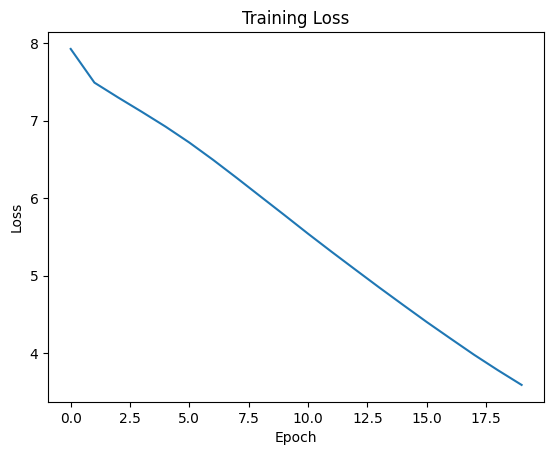

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()